# Face Detection with Haar Cascade

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Load cascade classifiers
face_cascade = cv2.CascadeClassifier("./haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier("./haarcascade_eye.xml")
mouth_cascade = cv2.CascadeClassifier("./haarcascade_mcs_mouth.xml")


def detect_faces(image):
    """Detect faces in an image"""
    faces = face_cascade.detectMultiScale(
        image,
    )
    return faces


def detect_eyes(image, face_rect):
    """Detect eyes within a face region"""

    x, y, w, h = face_rect
    face_roi = image[
        y : y + h // 2, x : x + w
    ]  # Only detect eyes in the upper half of the face

    eyes = eye_cascade.detectMultiScale(face_roi, scaleFactor=1.3, minNeighbors=5)
    eyes_absolute = [(ex + x, ey + y, ew, eh) for ex, ey, ew, eh in eyes]
    return eyes_absolute


def detect_mouth(image, face_rect):
    """Detect mouth within a face region"""

    x, y, w, h = face_rect
    face_roi = image[
        y + h // 2 : y + h, x : x + w
    ]  # Only detect mouth in the lower half of the face

    mouths = mouth_cascade.detectMultiScale(face_roi, scaleFactor=1.5, minNeighbors=15)
    mouths_absolute = [(mx + x, my + y + h // 2, mw, mh) for mx, my, mw, mh in mouths]
    return mouths_absolute


def draw_faces(image, faces, eyes=None, mouths=None):
    """Draw rectangles around faces and eyes"""
    result = image.copy()

    # Draw face rectangles (blue)
    for i, (x, y, w, h) in enumerate(faces):
        cv2.rectangle(result, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(
            result,
            f"Face {i+1}",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2,
        )

    # Draw eye rectangles (green)
    if eyes:
        for ex, ey, ew, eh in eyes:
            cv2.rectangle(result, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 1)

    # Draw mouth rectangles (red)
    if mouths:
        for mx, my, mw, mh in mouths:
            cv2.rectangle(result, (mx, my), (mx + mw, my + mh), (0, 0, 255), 1)

    return result


def show_face_detection(image_path, detect_eyes_flag=True, detect_mouths_flag=True):
    """Main function to detect and show faces"""
    # Load image
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"Could not load image: {image_path}")
        return None

    # Detect faces
    faces = detect_faces(image)
    print(f"Detected {len(faces)} face(s)")

    # Detect eyes
    all_eyes = []
    if detect_eyes_flag and len(faces) > 0:
        for face in faces:
            eyes = detect_eyes(image, face)
            all_eyes.extend(eyes)
        print(f"Detected {len(all_eyes)} eye(s)")

    # Detect mouths
    all_mouths = []
    if detect_mouths_flag and len(faces) > 0:
        for face in faces:
            mouths = detect_mouth(image, face)
            all_mouths.extend(mouths)
        print(f"Detected {len(all_mouths)} mouth(s)")

    # Draw detections
    result = draw_faces(
        image,
        faces,
        all_eyes if detect_eyes_flag else None,
        all_mouths if detect_mouths_flag else None,
    )

    # Display results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    ax2.set_title(
        f"Faces: {len(faces)}, Eyes: {len(all_eyes)}, Mouths: {len(all_mouths)}"
    )
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

    return faces, all_eyes, all_mouths


def get_face_coordinates(image_path):
    """Simple function to get face coordinates"""
    image = cv2.imread(str(image_path))
    if image is None:
        return []

    faces = detect_faces(image)
    print(f"Found {len(faces)} faces:")
    for i, (x, y, w, h) in enumerate(faces):
        print(f"Face {i+1}: x={x}, y={y}, width={w}, height={h}")

    return faces

Detected 4 face(s)
Detected 0 eye(s)
Detected 0 mouth(s)


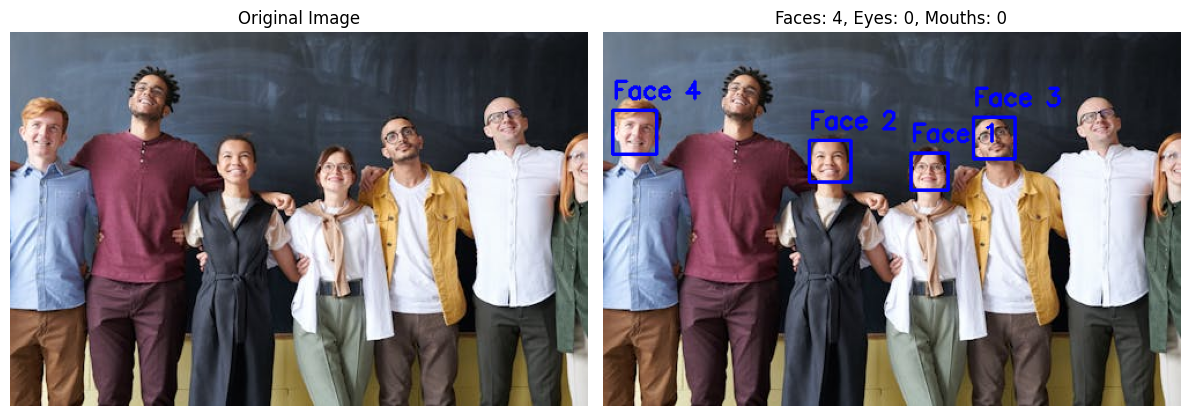

In [2]:
faces, eyes, mouths = show_face_detection('images/people.jpeg')

In [3]:
def webcam_face_detection(detect_eyes_flag=False, detect_mouths_flag=False):
    """Real-time face detection"""
    cap = cv2.VideoCapture(0)
    print("Press 'q' to quit")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        faces = detect_faces(frame)

        # Detect eyes
        all_eyes = []
        if detect_eyes_flag and len(faces) > 0:
            for face in faces:
                eyes = detect_eyes(frame, face)
                if len(eyes) > 2:
                    # Sort by area and take largest 2
                    eyes_sorted = sorted(eyes, key=lambda e: e[2] * e[3], reverse=True)
                    eyes = eyes_sorted[:2]
                all_eyes.extend(eyes)
            print(f"Detected {len(all_eyes)} eye(s)")

        # Detect mouths
        all_mouths = []
        if detect_mouths_flag and len(faces) > 0:
            for face in faces:
                mouths = detect_mouth(frame, face)
                if len(mouths) > 1:
                    # Take the largest one
                    mouths_sorted = sorted(
                        mouths, key=lambda m: m[2] * m[3], reverse=True
                    )
                    mouths = mouths_sorted[:1]
                all_mouths.extend(mouths)
            print(f"Detected {len(all_mouths)} mouth(s)")

        # Draw detections
        result = draw_faces(
            frame,
            faces,
            all_eyes if detect_eyes_flag else None,
            all_mouths if detect_mouths_flag else None,
        )

        cv2.imshow("Face Detection", result)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()


# Uncomment this to run the webcam face detection
# webcam_face_detection(detect_eyes_flag=True, detect_mouths_flag=True)

# Face Recognition with Eigenfaces

In [4]:
import numpy as np

data = np.load("./olivetti/versions/1/olivetti_faces.npy")
labels = np.load("./olivetti/versions/1/olivetti_faces_target.npy")



# print(data)
# print(labels)
# print(f"{len(data)} images")
# print(f"{len(np.unique(labels))} unique labels")
# print(f"Size: {data.shape[1]}x{data.shape[2]}")
# print(f"Pixel values were scaled to [0,1] interval. e.g:{data[0][0, :4]}")
# print("unique label number:",np.unique(labels))

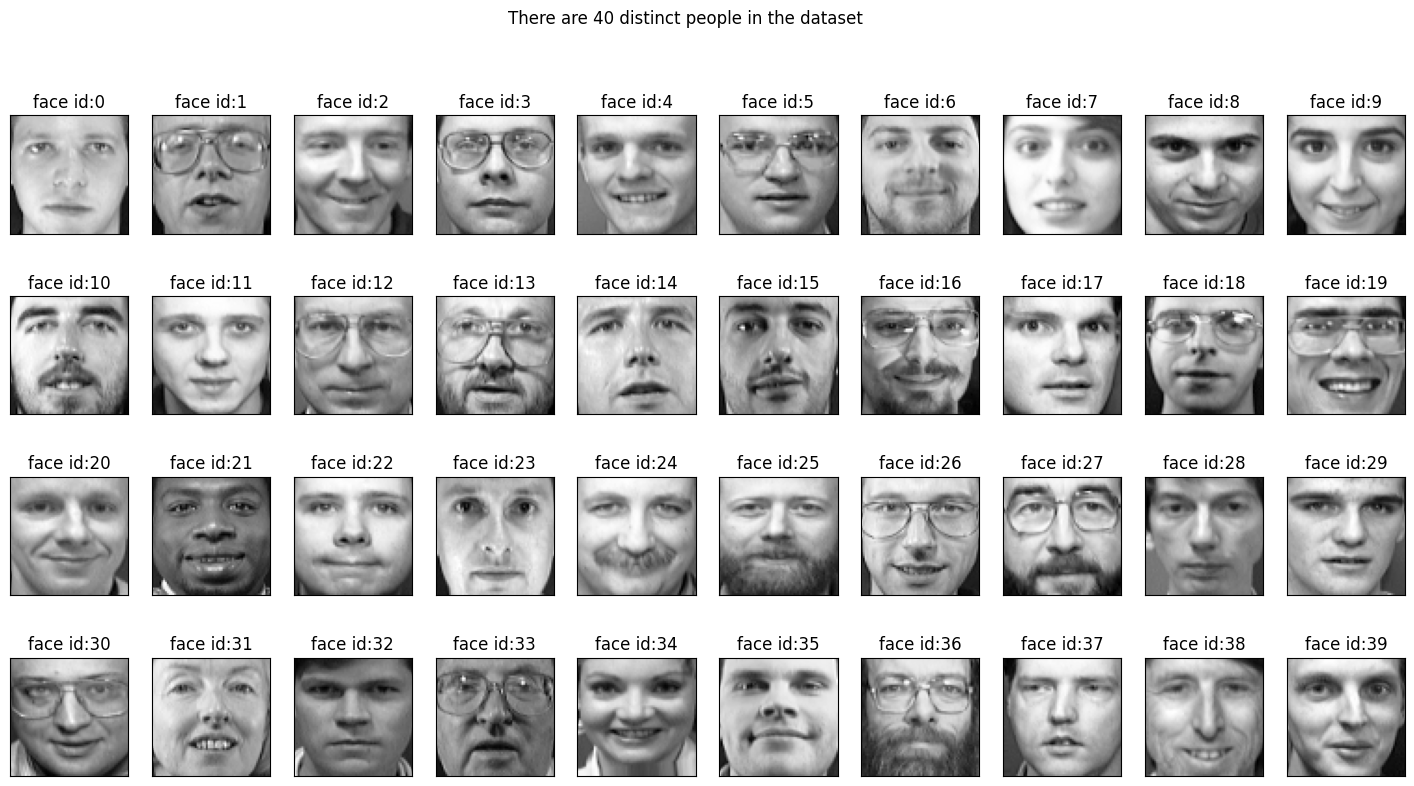

In [5]:
def show_all_people(images, unique_ids):
    fig, ax = plt.subplots(nrows=4, ncols=10, figsize=(18, 9))
    ax = ax.flatten()

    # iterating over user ids
    for unique_id in unique_ids:
        image_index = unique_id * 10
        ax[unique_id].imshow(images[image_index], cmap="gray")
        ax[unique_id].set_xticks([])
        ax[unique_id].set_yticks([])
        ax[unique_id].set_title(f"face id:{unique_id}")
    plt.suptitle("There are 40 distinct people in the dataset")


show_all_people(data, np.unique(labels))

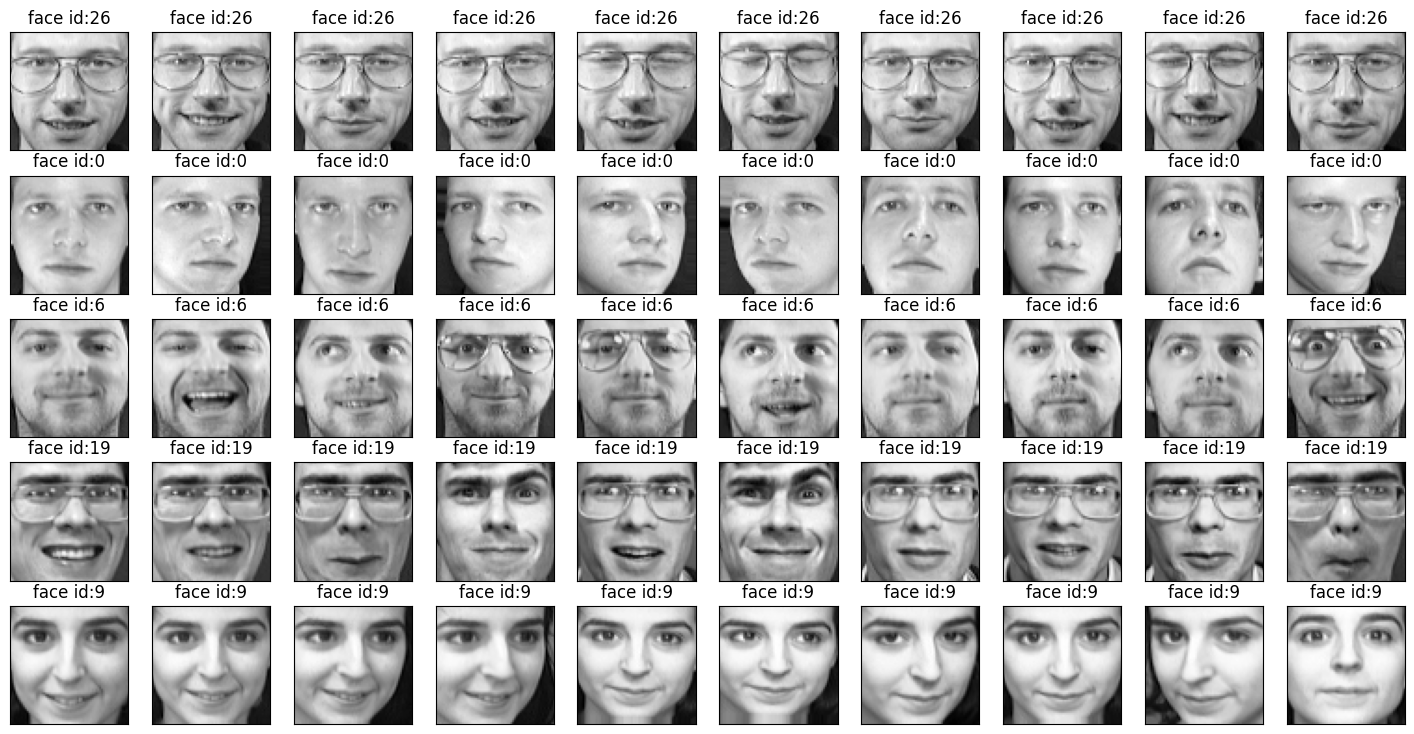

In [6]:
def show_all_faces_of_subject(images, subject_ids):
    cols = 10  # each subject has 10 distinct face images
    rows = (len(subject_ids) * 10) / cols
    rows = int(rows)

    fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(18, 9))

    for i, subject_id in enumerate(subject_ids):
        for j in range(cols):
            image_index = subject_id * 10 + j
            ax[i, j].imshow(images[image_index], cmap="gray")
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            ax[i, j].set_title(f"face id:{subject_id}")


show_all_faces_of_subject(images=data, subject_ids=[26, 0, 6, 19, 9])

In [7]:
X = data.reshape((data.shape[0], data.shape[1] * data.shape[2]))
print("X shape:", X.shape)
print(data.shape)

X shape: (400, 4096)
(400, 64, 64)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels,
    test_size=0.3,
    stratify=labels,  # ensure the same distribution of labels in train and test e.g: 100 samples of label 0 in train and 100 samples of label 0 in test
    random_state=0,
)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (280, 4096)
y_train shape: (280,)
X_test shape: (120, 4096)
y_test shape: (120,)


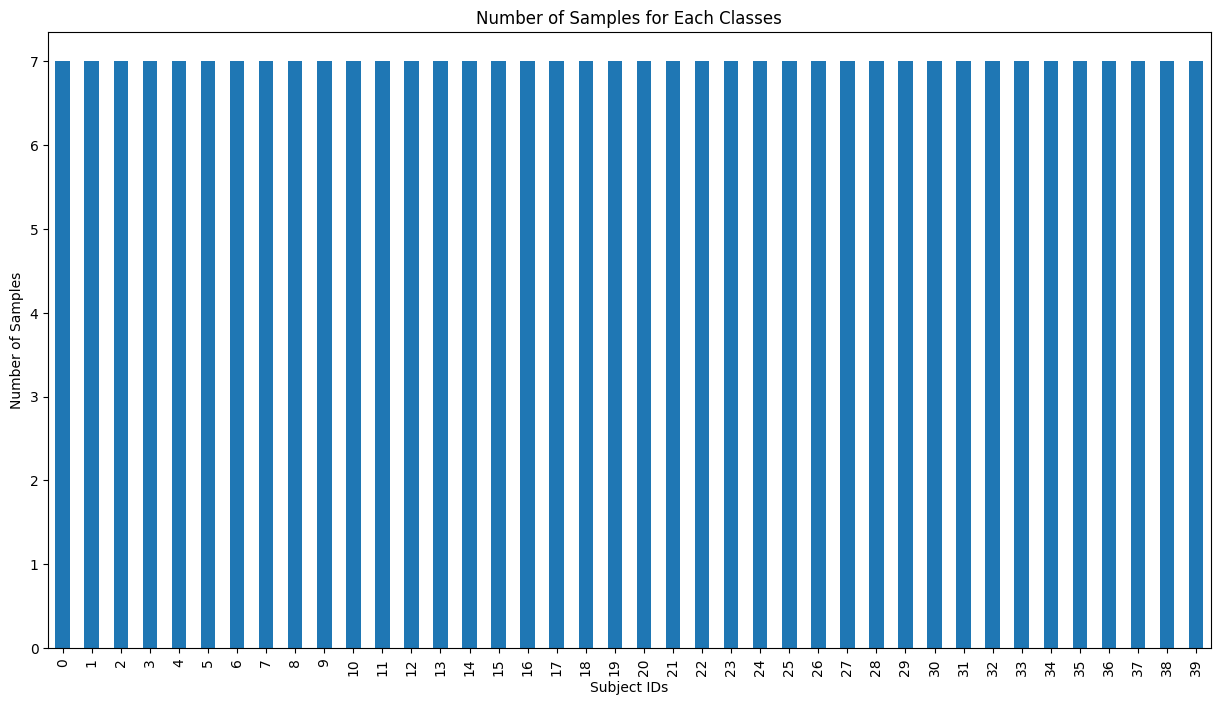

In [9]:
import pandas as pd

y_frame = pd.DataFrame()
y_frame["subject ids"] = y_train
# group by subject ids and plot the number of samples for each class
y_frame.groupby(["subject ids"]).size().plot.bar(
    figsize=(15, 8),
    title="Number of Samples for Each Classes",
    xlabel="Subject IDs",
    ylabel="Number of Samples",
)
plt.show()

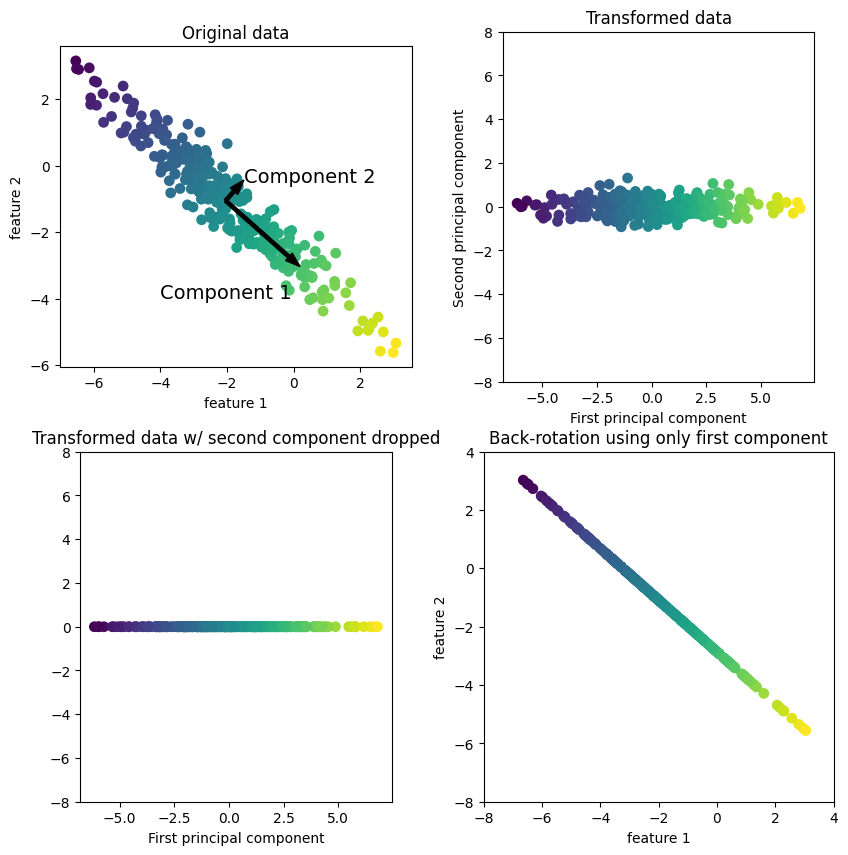

In [10]:
import mglearn
mglearn.plots.plot_pca_illustration()

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

print(X_pca.shape)
print(X_pca[0])

(400, 2)
[6.432663   0.70365524]


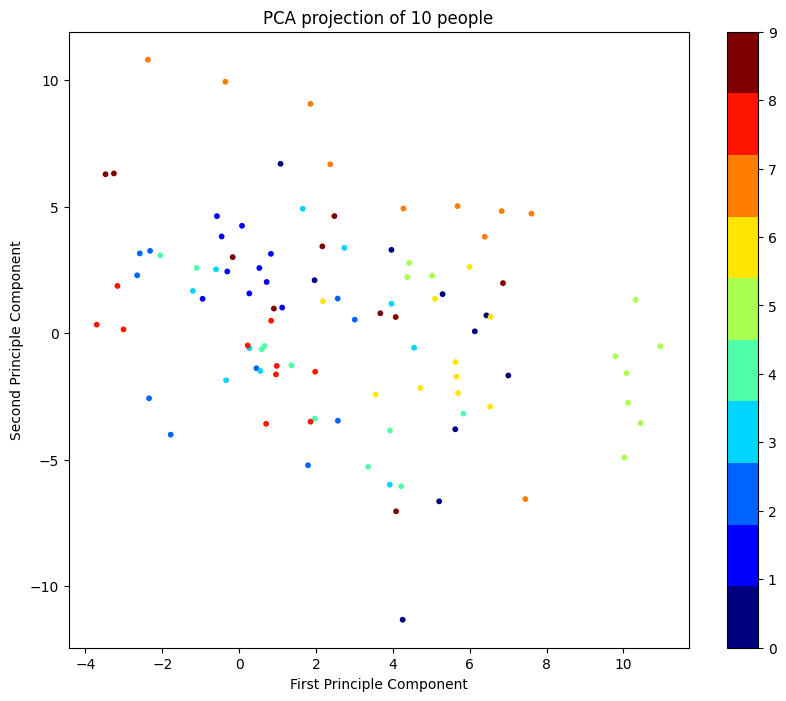

In [12]:
number_of_people = 10
index_range = number_of_people * 10
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1)
scatter = ax.scatter(
    X_pca[:index_range, 0],
    X_pca[:index_range, 1],
    c=labels[:index_range],  # Color each point by its label
    s=10,
    cmap=plt.get_cmap("jet", number_of_people),  # Colormap: 40 distinct colors
)

ax.set_xlabel("First Principle Component")
ax.set_ylabel("Second Principle Component")
ax.set_title(f"PCA projection of {number_of_people} people")

fig.colorbar(scatter)

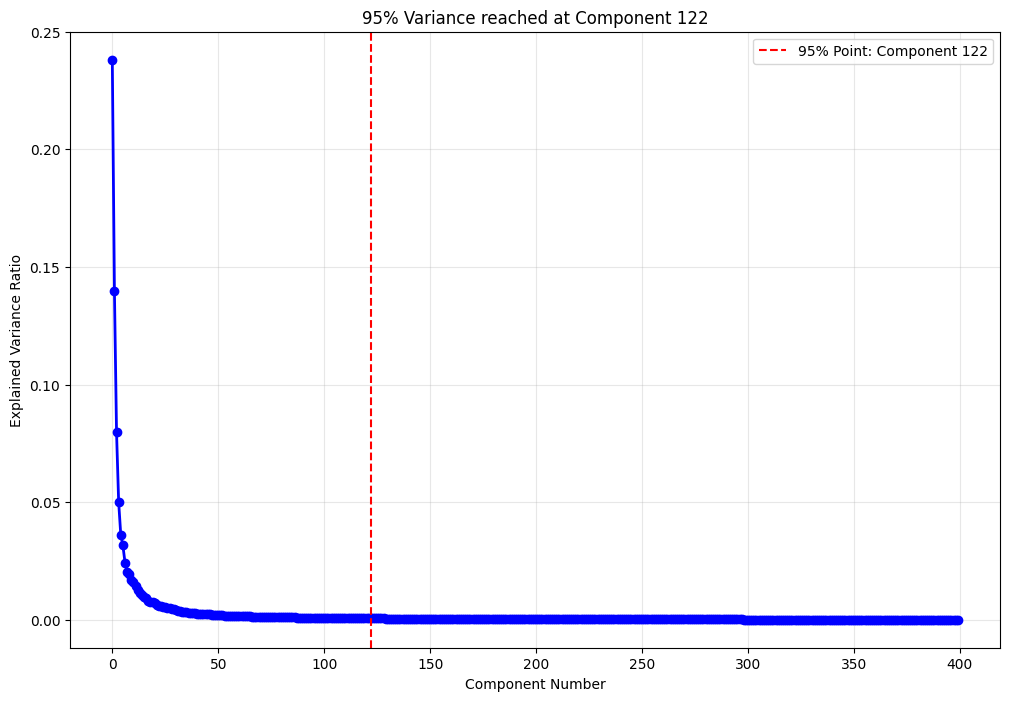

95% Variance Point: Component 122
Variance at this point: 0.1%
Cumulative variance: 95.0%


In [13]:
pca = PCA()
pca.fit(X)

# Use consistent data type
explained_var_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(12, 8))
plt.plot(explained_var_ratio, "bo-", linewidth=2)


def get_95_percent_point(explained_variance_ratio):  # Renamed for clarity
    cumulative_var = np.cumsum(explained_variance_ratio)
    point_95 = np.argmax(cumulative_var >= 0.95)
    return point_95


point_95 = get_95_percent_point(explained_var_ratio)  # Calculate the 95% point

# Show 95% point on plot
plt.axvline(
    x=point_95, color="red", linestyle="--", label=f"95% Point: Component {point_95}"
)

plt.xlabel("Component Number")
plt.ylabel("Explained Variance Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f"95% Variance reached at Component {point_95}")
plt.show()

print(f"95% Variance Point: Component {point_95}")
print(f"Variance at this point: {explained_var_ratio[point_95]:.1%}")
print(f"Cumulative variance: {np.sum(explained_var_ratio[:point_95+1]):.1%}")

In [14]:
pca = PCA(n_components=point_95, whiten=True)
pca.fit(X_train)

PCA(n_components=np.int64(122), whiten=True)

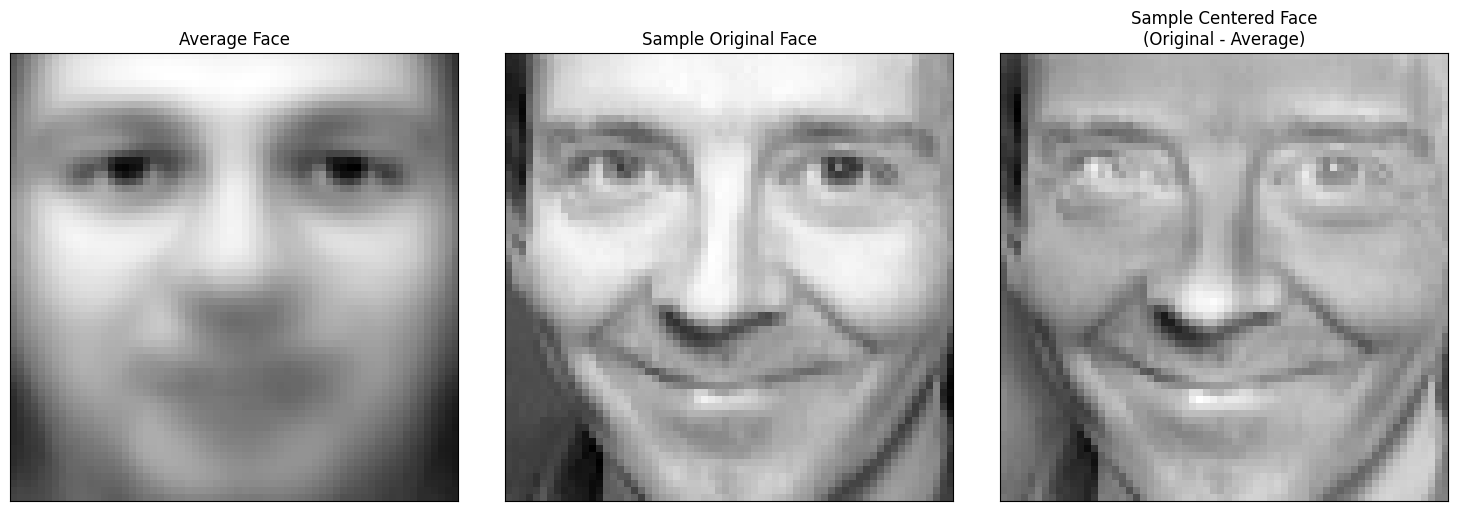

Average face pixel range: 0.2 to 0.7
Average face mean value: 0.5


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Average face
axes[0].imshow(pca.mean_.reshape((64, 64)), cmap="gray")
axes[0].set_title("Average Face")
axes[0].set_xticks([])
axes[0].set_yticks([])

# Sample original face
axes[1].imshow(X[26].reshape((64, 64)), cmap="gray")
axes[1].set_title("Sample Original Face")
axes[1].set_xticks([])
axes[1].set_yticks([])

# Centered face (original - average)
centered_face = X[26] - pca.mean_
axes[2].imshow(centered_face.reshape((64, 64)), cmap="gray")
axes[2].set_title("Sample Centered Face\n(Original - Average)")
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

# Print statistics
print(f"Average face pixel range: {pca.mean_.min():.1f} to {pca.mean_.max():.1f}")
print(f"Average face mean value: {pca.mean_.mean():.1f}")

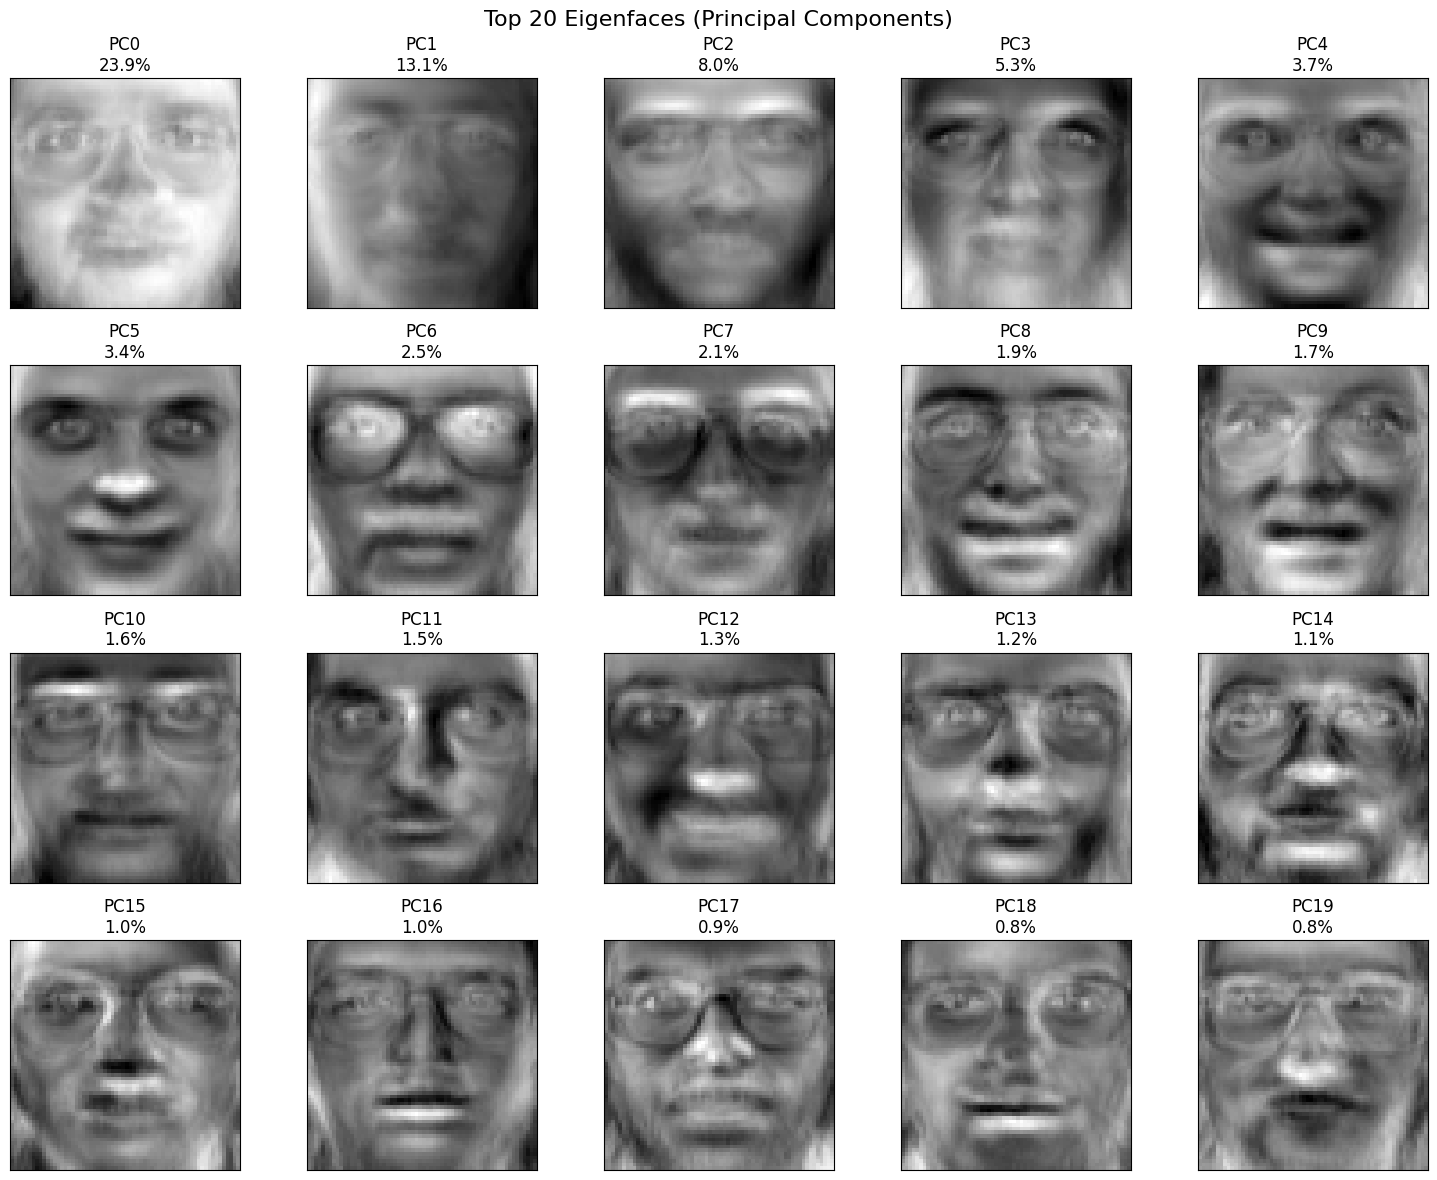

Eigenface Interpretation Guide:
Each eigenface is a template that captures a specific type of variation between faces
Early eigenfaces = important patterns (lighting, shape, major features)
E.g: Lighting differences (35%) ← PC0 captures THIS
Later eigenfaces = minor details and noise


In [16]:
number_of_eigenfaces = len(pca.components_)
eigen_faces = pca.components_.reshape((number_of_eigenfaces, 64, 64))

# Show first 20 most important eigenfaces
n_show = min(20, number_of_eigenfaces)
cols = 5
rows = int(np.ceil(n_show / cols))

fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 12))
ax = ax.flatten()

for i in range(n_show):
    ax[i].imshow(eigen_faces[i], cmap="gray")
    ax[i].set_xticks([])
    ax[i].set_yticks([])

    # Add variance information to title
    variance_pct = pca.explained_variance_ratio_[i] * 100
    ax[i].set_title(f"PC{i}\n{variance_pct:.1f}%")

# Hide unused subplots
for i in range(n_show, len(ax)):
    ax[i].axis("off")

plt.suptitle("Top 20 Eigenfaces (Principal Components)", fontsize=16)
plt.tight_layout()
plt.show()

# Print interpretation
print("Eigenface Interpretation Guide:")
print("=" * 40)
print(
    "Each eigenface is a template that captures a specific type of variation between faces"
)
print("Early eigenfaces = important patterns (lighting, shape, major features)")
print("E.g: Lighting differences (35%) ← PC0 captures THIS")
print("Later eigenfaces = minor details and noise")

In [17]:
# Transform data to eigenface space
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# Print comprehensive transformation summary
print("=" * 50)
print("PCA TRANSFORMATION RESULTS")
print("=" * 50)

# Shape information
print(f"Original data shape:")
print(f"  Training:  {X_train.shape}")
print(f"  Test:      {X_test.shape}")

print(f"\nTransformed data shape:")
print(f"  Training:  {X_train_pca.shape}")
print(f"  Test:      {X_test_pca.shape}")

# Compression info
compression_ratio = X_train.shape[1] / X_train_pca.shape[1]
print(f"\nCompression: {X_train.shape[1]} → {X_train_pca.shape[1]} dimensions")
print(f"Compression ratio: {compression_ratio:.0f}:1")

# Sample coefficients
print(f"\nSample eigenface coefficients:")
print(f"First training sample: {X_train_pca[0][:5].round(2)}... (first 5)")
print(f"First test sample:     {X_test_pca[0][:5].round(2)}... (first 5)")

# Variance information  
print(f"\nVariance explained by components:")
for i in range(min(5, len(pca.explained_variance_ratio_))):
    print(f"  PC{i}: {pca.explained_variance_ratio_[i]:.1%}")

total_variance = pca.explained_variance_ratio_.sum()
print(f"\nTotal variance explained: {total_variance:.1%}")

print("=" * 50)

PCA TRANSFORMATION RESULTS
Original data shape:
  Training:  (280, 4096)
  Test:      (120, 4096)

Transformed data shape:
  Training:  (280, 122)
  Test:      (120, 122)

Compression: 4096 → 122 dimensions
Compression ratio: 34:1

Sample eigenface coefficients:
First training sample: [ 0.72  1.24 -1.11 -1.5  -0.01]... (first 5)
First test sample:     [ 1.38 -1.04  0.09  0.38  0.29]... (first 5)

Variance explained by components:
  PC0: 23.9%
  PC1: 13.1%
  PC2: 8.0%
  PC3: 5.3%
  PC4: 3.7%

Total variance explained: 96.1%


In [18]:
from sklearn.svm import SVC
from sklearn import metrics
import numpy as np

# Train classifier
clf = SVC()
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)

# Results summary
print("=" * 50)
print("FACE RECOGNITION RESULTS")
print("=" * 50)

# Basic accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
total_samples = len(y_test)
correct = int(accuracy * total_samples)
wrong = total_samples - correct

print(f"Total test samples: {total_samples}")
print(f"Correct predictions: {correct}")
print(f"Wrong predictions: {wrong}")
print(f"Accuracy: {accuracy:.1%}")

# Show sample predictions
print(f"\nSample Predictions (first 10):")
print("True → Pred | Status")
print("-" * 20)
for i in range(min(10, len(y_test))):
    true_label = y_test[i]
    pred_label = y_pred[i]
    status = "✓" if true_label == pred_label else "✗"
    print(f"  {true_label:2d} →  {pred_label:2d}  |   {status}")

# Find worst errors (if any)
if wrong > 0:
    print(f"\nMisclassified examples:")
    errors = np.where(y_test != y_pred)[0]
    for i in errors[:5]:  # Show first 5 errors
        print(f"  Sample {i}: True={y_test[i]}, Predicted={y_pred[i]}")

print("=" * 50)

FACE RECOGNITION RESULTS
Total test samples: 120
Correct predictions: 110
Wrong predictions: 10
Accuracy: 91.7%

Sample Predictions (first 10):
True → Pred | Status
--------------------
   4 →  39  |   ✗
  10 →  10  |   ✓
  33 →  33  |   ✓
   7 →   3  |   ✗
  37 →  37  |   ✓
  10 →  10  |   ✓
  28 →  28  |   ✓
   4 →   4  |   ✓
  27 →  27  |   ✓
   2 →  20  |   ✗

Misclassified examples:
  Sample 0: True=4, Predicted=39
  Sample 3: True=7, Predicted=3
  Sample 9: True=2, Predicted=20
  Sample 15: True=3, Predicted=20
  Sample 20: True=25, Predicted=2


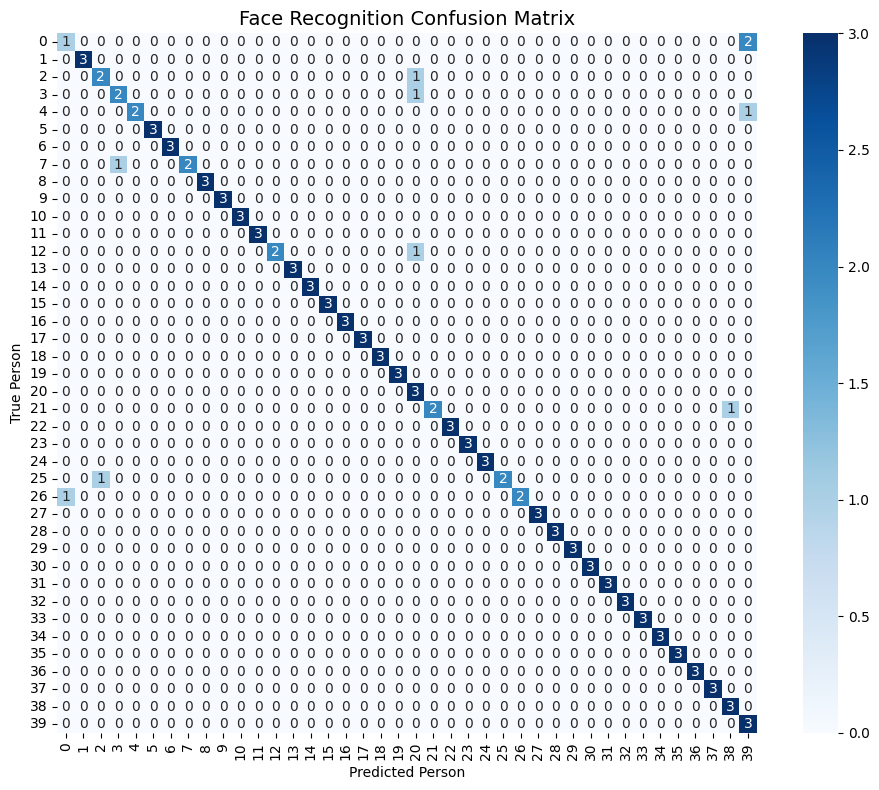

DETAILED CLASSIFICATION REPORT
Precision: When I say it's Person X, how often am I right?
Recall: How often do I correctly identify Person X?
F1-Score: Balance between precision and recall. Great balance: finds most faces AND is accurate when it does
Support: How many samples of Person X are there?
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       1.00      1.00      1.00         3
           2       0.67      0.67      0.67         3
           3       0.67      0.67      0.67         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      0.67      0.80         3
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00        

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics

# Create confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)

# Improved heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,  # Show numbers
    fmt="d",  # Integer format
    cmap="Blues",  # ]
    square=True,
)  # Square cells

plt.title("Face Recognition Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Person")
plt.ylabel("True Person")
plt.tight_layout()
plt.show()

# Clean classification report
print("=" * 50)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 50)
print("Precision: When I say it's Person X, how often am I right?")
print("Recall: How often do I correctly identify Person X?")
print(
    "F1-Score: Balance between precision and recall. Great balance: finds most faces AND is accurate when it does"
)
print("Support: How many samples of Person X are there?")
print("=" * 50)
print(metrics.classification_report(y_test, y_pred))

In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn import metrics
import time

# Define models
models = [
    ("LDA", LinearDiscriminantAnalysis()),
    ("Logistic Regression", LogisticRegression()),
    ("Naive Bayes", GaussianNB()),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier()),
    ("Support Vector Machine", SVC()),
]

# Store results
results = []

print("=" * 60)
print("CLASSIFIER COMPARISON FOR FACE RECOGNITION")
print("=" * 60)
print(f"Training samples: {X_train_pca.shape[0]}")
print(f"Test samples: {X_test_pca.shape[0]}")
print(f"Features (eigenfaces): {X_train_pca.shape[1]}")
print("=" * 60)

for name, model in models:
    # Train and time the model
    start_time = time.time()
    model.fit(X_train_pca, y_train)
    train_time = time.time() - start_time

    # Predict and time
    start_time = time.time()
    y_pred = model.predict(X_test_pca)
    predict_time = time.time() - start_time

    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_pred)

    # Store results
    results.append((name, accuracy, train_time, predict_time))

    print(
        f"{name:20s}: {accuracy:.1%} (Train: {train_time:.3f}s, Predict time: {predict_time:.3f}s)"
    )

# Find best model
best_model = max(results, key=lambda x: x[1])
print("=" * 60)
print(f"BEST PERFORMER: {best_model[0]} with {best_model[1]:.1%} accuracy")
print("=" * 60)

# Sort by accuracy
print("\nRankings:")
sorted_results = sorted(results, key=lambda x: x[1], reverse=True)
for i, (name, acc, train_t, pred_t) in enumerate(sorted_results, 1):
    print(f"{i}. {name}: {acc:.1%}")

CLASSIFIER COMPARISON FOR FACE RECOGNITION
Training samples: 280
Test samples: 120
Features (eigenfaces): 122
LDA                 : 93.3% (Train: 0.004s, Predict time: 0.000s)
Logistic Regression : 92.5% (Train: 0.005s, Predict time: 0.000s)
Naive Bayes         : 85.8% (Train: 0.001s, Predict time: 0.003s)
K-Nearest Neighbors : 62.5% (Train: 0.000s, Predict time: 0.037s)
Decision Tree       : 59.2% (Train: 0.032s, Predict time: 0.000s)
Support Vector Machine: 91.7% (Train: 0.010s, Predict time: 0.004s)
BEST PERFORMER: LDA with 93.3% accuracy

Rankings:
1. LDA: 93.3%
2. Logistic Regression: 92.5%
3. Support Vector Machine: 91.7%
4. Naive Bayes: 85.8%
5. K-Nearest Neighbors: 62.5%
6. Decision Tree: 59.2%


We're picking the best classifier: LDA

In [21]:
clf = LinearDiscriminantAnalysis()
clf.fit(X_train_pca, y_train)

LinearDiscriminantAnalysis()

Face Recognition Results:
Face 1: ✓ True=4, Pred=4, Conf=88.6%
Face 2: ✓ True=10, Pred=10, Conf=100.0%
Face 3: ✓ True=33, Pred=33, Conf=100.0%
Face 4: ✗ True=7, Pred=39, Conf=100.0%
Face 5: ✓ True=37, Pred=37, Conf=100.0%
Face 6: ✓ True=10, Pred=10, Conf=100.0%
Face 7: ✓ True=28, Pred=28, Conf=100.0%
Face 8: ✓ True=4, Pred=4, Conf=100.0%
Face 9: ✓ True=27, Pred=27, Conf=100.0%
Face 10: ✓ True=2, Pred=2, Conf=100.0%


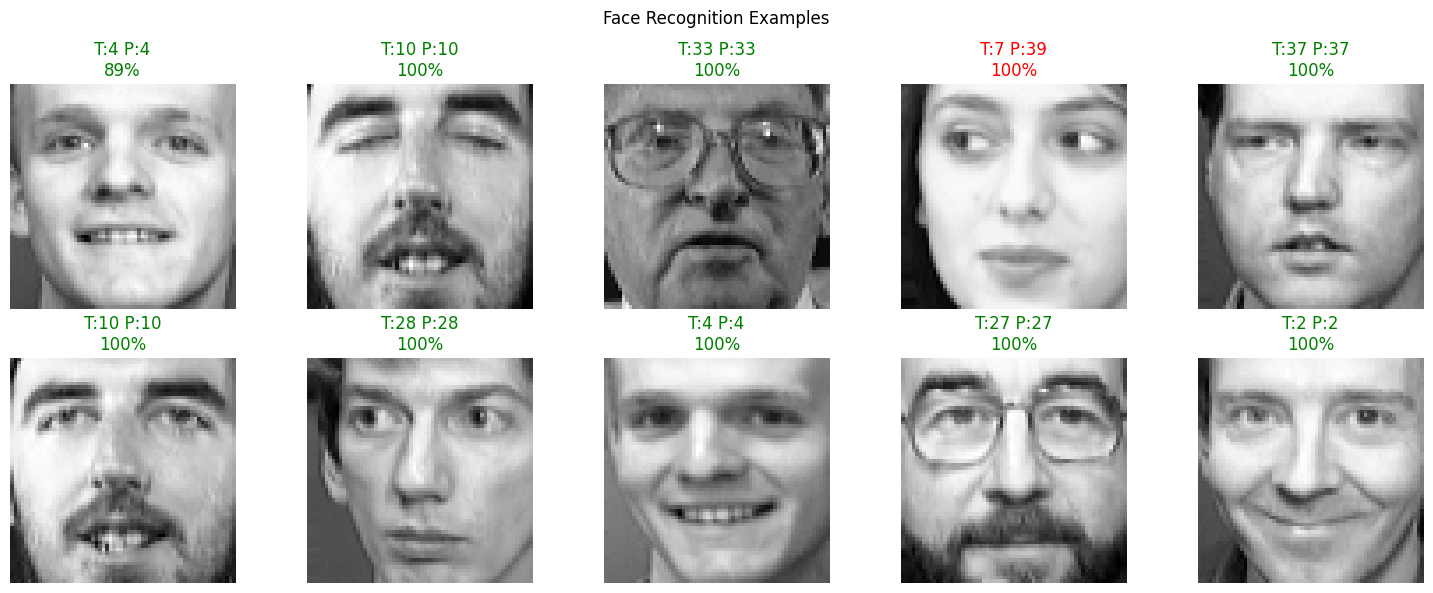

In [24]:
# Step 1: Use your already trained model
# (assuming you already have pca, clf, X_test, y_test from previous steps)


# Step 2: Simple face recognition function
def recognize_face(face_index):
    """Recognize a face from test set"""
    # Get the face
    face_pca = X_test_pca[face_index : face_index + 1]

    # Predict
    prediction = clf.predict(face_pca)[0]
    confidence = clf.predict_proba(face_pca)[0].max()

    return prediction, confidence


def test_recognition(offset=0):
    offset = min(offset, len(X_test) - 10)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(10):
        # Get face image
        face_image = X_test[i + offset].reshape(64, 64)

        # Recognize
        pred_person, confidence = recognize_face(i + offset)
        true_person = y_test[i + offset]

        status = "✓" if pred_person == true_person else "✗"
        print(
            f"Face {i+offset+1}: {status} True={true_person}, Pred={pred_person}, Conf={confidence:.1%}"
        )

        # Show image
        axes[i].imshow(face_image, cmap="gray")

        # Title with result
        color = "green" if pred_person == true_person else "red"
        axes[i].set_title(
            f"T:{true_person} P:{pred_person}\n{confidence:.0%}",
            color=color,
            fontsize=12,
        )
        axes[i].axis("off")

    plt.suptitle("Face Recognition Examples")
    plt.tight_layout()
    plt.show()


print("Face Recognition Results:")
print("=" * 30)
test_recognition(0)